In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

def add_source(fig, text):
    """Write the data source under the chart."""
    fig.text(0.01, 0.005, text, fontsize=8, color="#666666", ha="left", va="bottom")

In [2]:
path = "https://raw.githubusercontent.com/AndrewEberhardt/DataScienceProject/main/data/raw/crops/soybean-production.csv"
soy= pd.read_csv(path)
soy.head() 

,Entity,Code,Year,Soybeans - Production (tonnes)
0,Afghanistan,AFG,2022,2906.0
1,Afghanistan,AFG,2023,6000.0
2,Afghanistan,AFG,2024,7304.9
3,Africa,OWID_AFR,1961,71813.0
4,Africa,OWID_AFR,1962,84594.0


In [3]:
soy_world = soy[soy["Entity"] == "World"].reset_index(drop=True)
soy_world.head()


,Entity,Code,Year,Soybeans - Production (tonnes)
0,World,OWID_WRL,1961,26883158.0
1,World,OWID_WRL,1962,27120148.0
2,World,OWID_WRL,1963,28207072.0
3,World,OWID_WRL,1964,29079548.0
4,World,OWID_WRL,1965,31704924.0


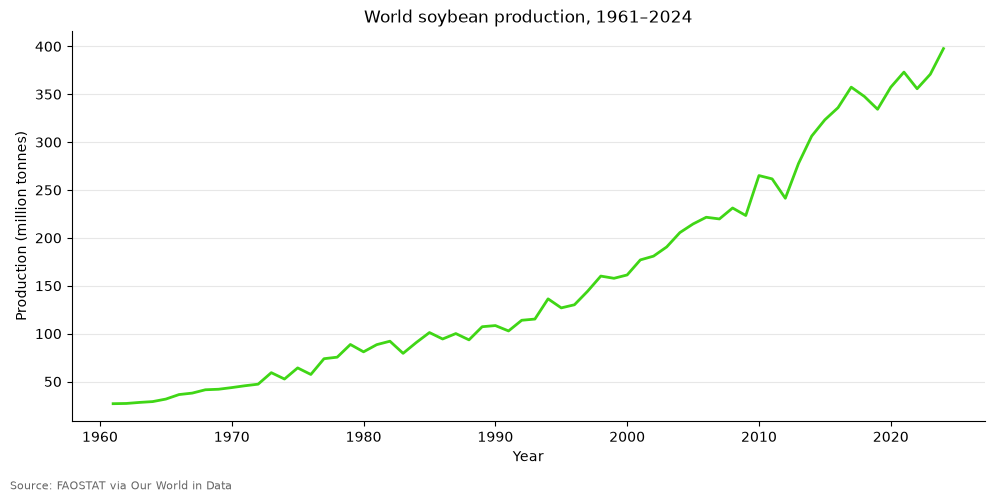

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(soy_world["Year"], soy_world["Soybeans - Production (tonnes)"] / 1e6, color="#40d616", linewidth=2)
ax.set_title("World soybean production, 1961–2024")
ax.set_xlabel("Year")
ax.set_ylabel("Production (million tonnes)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()


In [5]:

soy_pays = soy[soy["Code"].notna() & ~soy["Code"].str.startswith("OWID_")]

prod_par_pays = (
    soy_pays.groupby("Entity")["Soybeans - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Soybeans - Production (tonnes)": "production_totale_t"})
)
prod_par_pays.head(20)


,pays,production_totale_t
0,United States,4.163381e+09
1,Brazil,2.567028e+09
2,Argentina,1.270650e+09
3,China,7.698996e+08
4,India,3.248761e+08
5,Paraguay,2.102788e+08
6,Canada,1.579355e+08
7,Bolivia,6.629038e+07
8,Russia,6.397409e+07
9,Ukraine,5.963436e+07


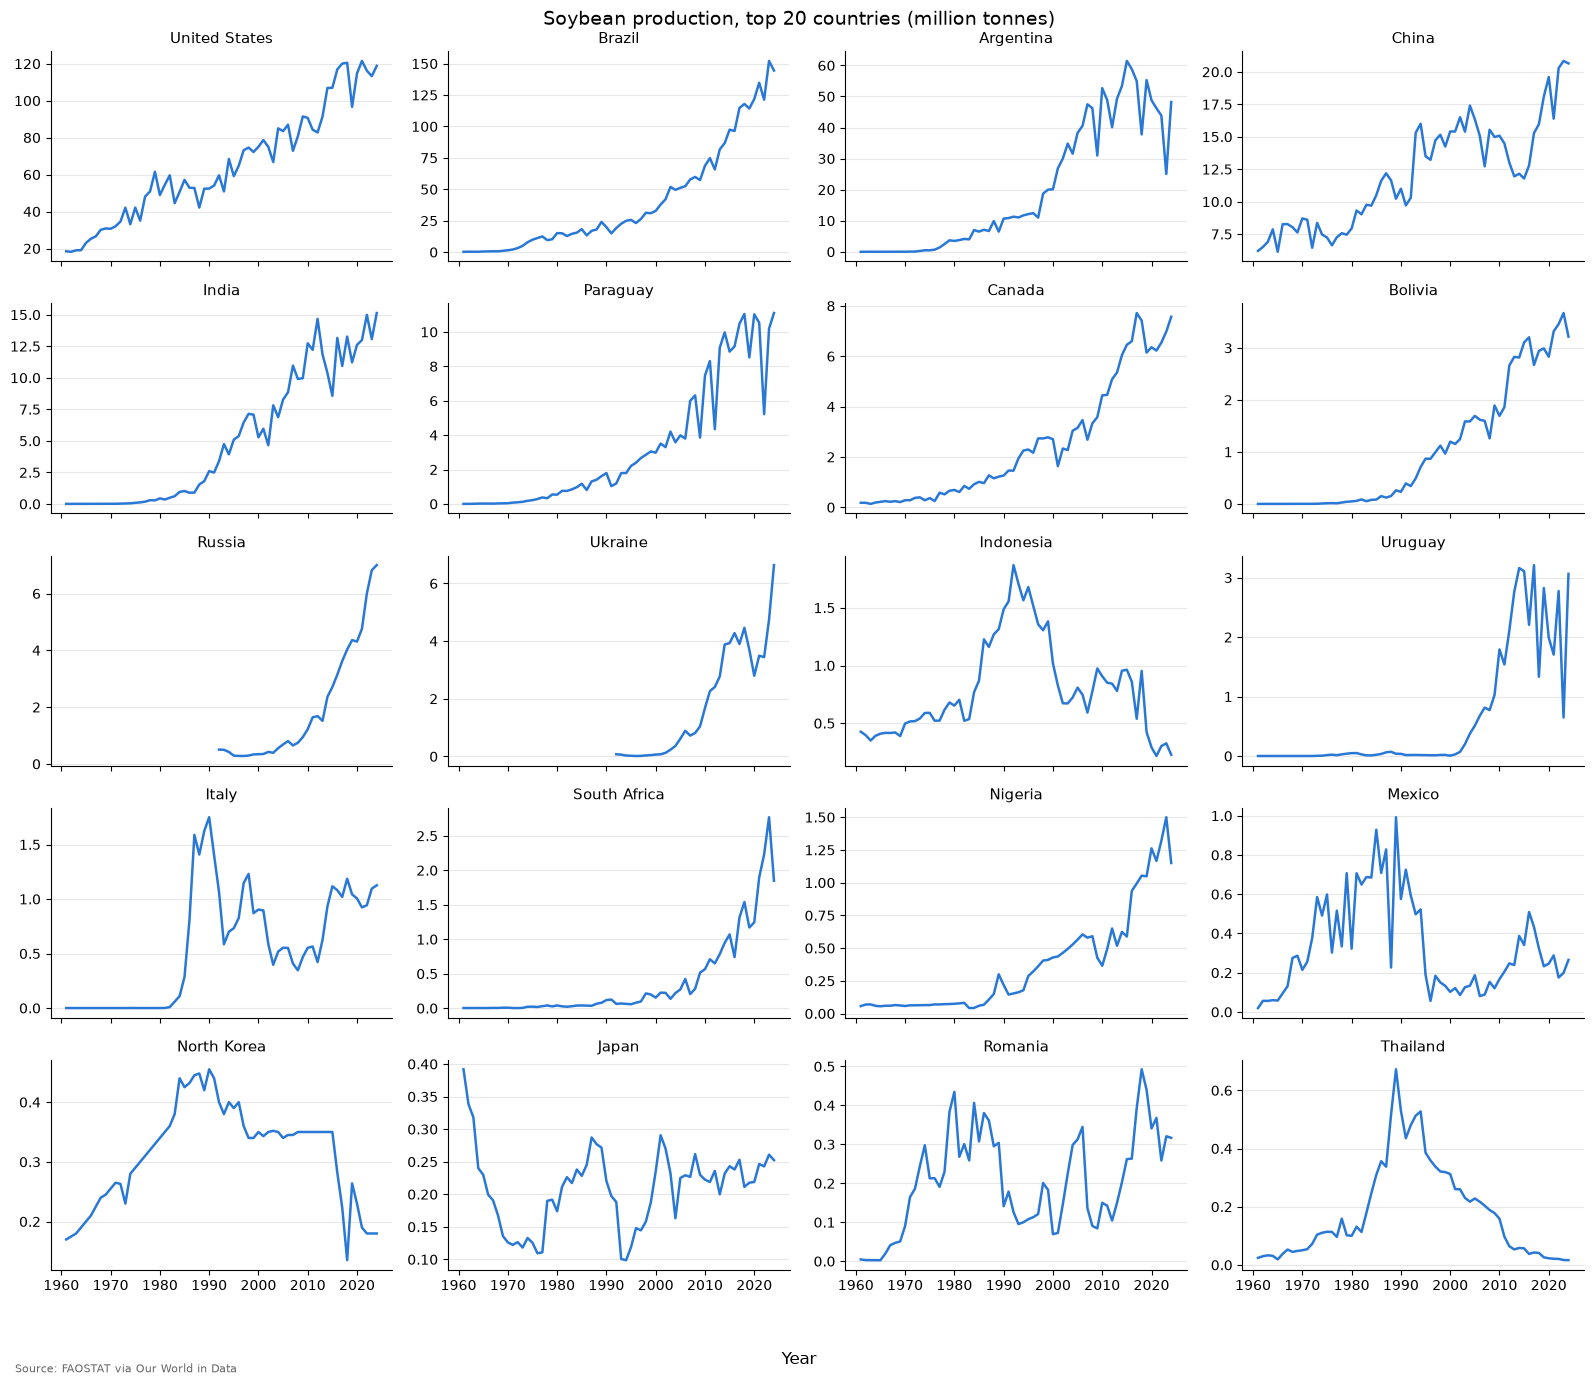

In [6]:
top20 = prod_par_pays.head(20)["pays"].tolist()
data = soy_pays[soy_pays["Entity"].isin(top20)]

fig, axes = plt.subplots(5, 4, figsize=(16, 14), sharex=True)
for ax, pays in zip(axes.flat, top20):
    d = data[data["Entity"] == pays]
    ax.plot(d["Year"], d["Soybeans - Production (tonnes)"] / 1e6, color="#2a78d6", linewidth=1.8)
    ax.set_title(pays, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Soybean production, top 20 countries (million tonnes)", fontsize=14)
fig.supxlabel("Year")
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()


In [7]:
prod_par_pays["part_%"] = prod_par_pays["production_totale_t"] / prod_par_pays["production_totale_t"].sum() * 100
prod_par_pays.head

<bound method NDFrame.head of               pays  production_totale_t     part_%
0    United States         4.163381e+09  41.459014
1           Brazil         2.567028e+09  25.562504
2        Argentina         1.270650e+09  12.653155
3            China         7.698996e+08   7.666673
4            India         3.248761e+08   3.235121
..             ...                  ...        ...
113        Finland         0.000000e+00   0.000000
114          Malta         0.000000e+00   0.000000
115         Latvia         0.000000e+00   0.000000
116        Ireland         0.000000e+00   0.000000
117        Estonia         0.000000e+00   0.000000

[118 rows x 3 columns]>

In [8]:
soy_pays = soy[soy["Code"].notna()
               & ~soy["Code"].str.startswith("OWID_")
               & (soy["Year"] >= 1996)]

prod_par_pays = (
    soy_pays.groupby("Entity")["Soybeans - Production (tonnes)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"Entity": "pays", "Soybeans - Production (tonnes)": "production_totale_t"})
)
prod_par_pays["part_%"] = prod_par_pays["production_totale_t"] / prod_par_pays["production_totale_t"].sum() * 100

gros_producteurs_soy = prod_par_pays.loc[prod_par_pays["part_%"] > 1, "pays"].tolist()
gros_producteurs_soy


['United States',
 'Brazil',
 'Argentina',
 'China',
 'India',
 'Paraguay',
 'Canada']

Argentina', 'Australia', 'Bangladesh', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil', 'Cambodia', 'Colombia', 'Ecuador', 'Ethiopia', 'India', 'Indonesia', "Lao People's Democratic Republic", 'Malawi', 'Nepal', 'Nicaragua', 'Nigeria', 'Paraguay', 'Peru', 'Philippines', 'South Africa', 'Sri Lanka', 'Thailand', 'Viet Nam', 'Zimbabwe

In [9]:
pays_soy = ['Argentina', 'Australia', 'Bangladesh', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil',
            'Cambodia', 'Colombia', 'Ecuador', 'Ethiopia', 'India', 'Indonesia',
            "Lao People's Democratic Republic", 'Malawi', 'Nepal', 'Nicaragua', 'Nigeria', 'Paraguay',
            'Peru', 'Philippines', 'South Africa', 'Sri Lanka', 'Thailand', 'Viet Nam', 'Zimbabwe']

communs = sorted(set(pays_soy) & set(gros_producteurs_soy))
communs


['Argentina', 'Brazil', 'India', 'Paraguay']

These country lists describe who produces the crop. They do not choose the sample of the analysis: the regressions use every country of the deforestation panel, weighted by its own exposure.

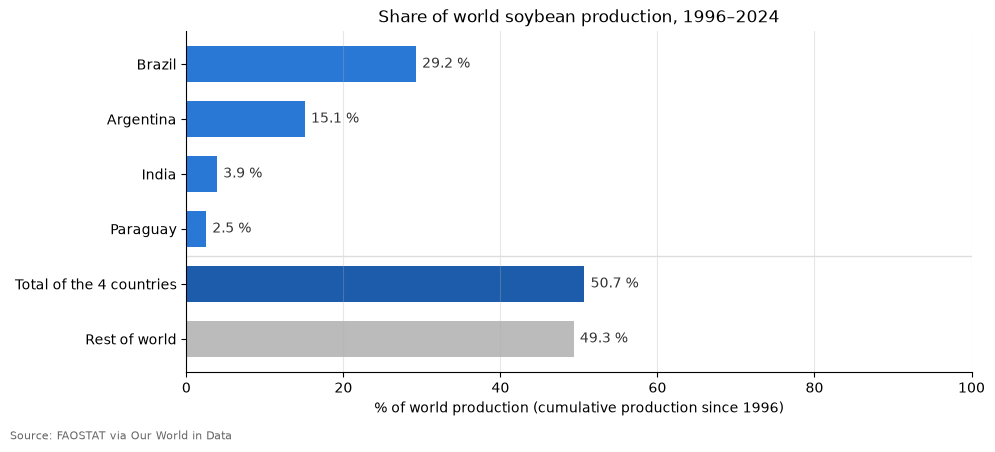

In [10]:
pays_retenus = ["Brazil", "Argentina", "India", "Paraguay"]

part = prod_par_pays.set_index("pays").loc[pays_retenus, "part_%"].sort_values()
total_4 = part.sum()

barres = pd.concat([
    pd.Series({"Rest of world": 100 - total_4, "Total of the 4 countries": total_4}),
    part,
])
couleurs = ["#bbbbbb", "#1c5cab"] + ["#2a78d6"] * len(part)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(barres.index, barres.values, color=couleurs, height=0.65)
for i, v in enumerate(barres.values):
    ax.text(v + 0.8, i, f"{v:.1f} %", va="center", fontsize=10, color="#333333")

ax.axhline(1.5, color="#dddddd", linewidth=1)
ax.set_title("Share of world soybean production, 1996–2024")
ax.set_xlabel("% of world production (cumulative production since 1996)")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()


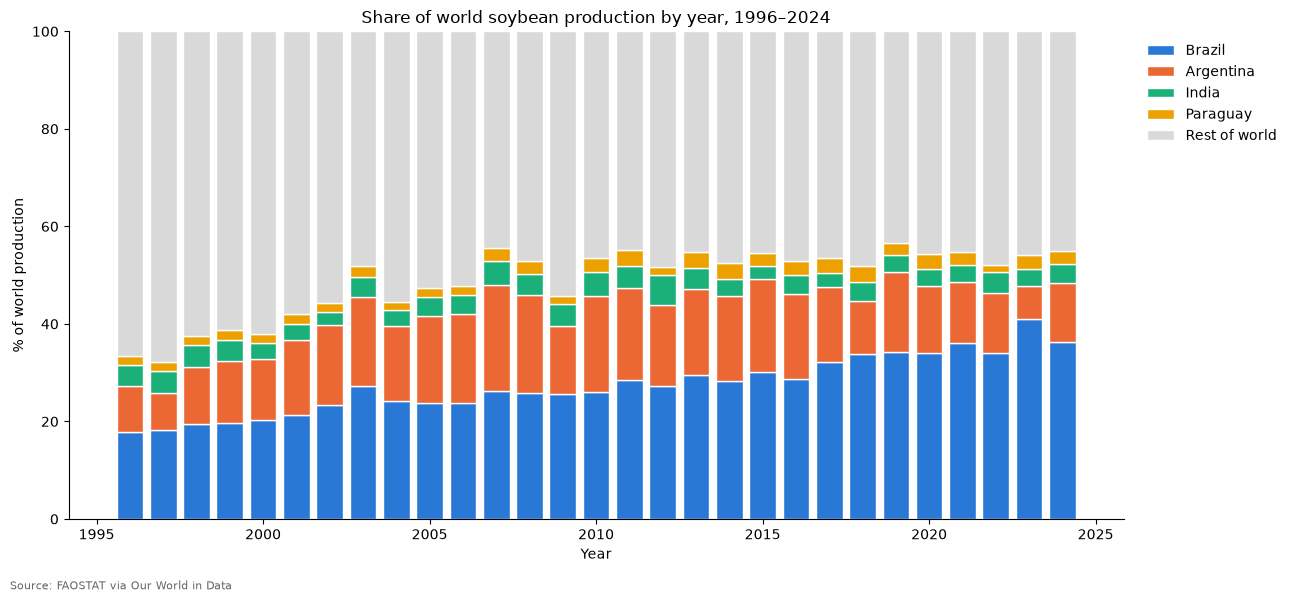

In [11]:
soy2 = pd.read_csv(path)
col = "Soybeans - Production (tonnes)"
pays_retenus = ["Brazil", "Argentina", "India", "Paraguay"]

# Production par pays et par année, depuis 1996
soy_96 = soy2[soy2["Year"] >= 1996]
monde = soy_96[soy_96["Entity"] == "World"].set_index("Year")[col]

parts = (soy_96[soy_96["Entity"].isin(pays_retenus)]
         .pivot(index="Year", columns="Entity", values=col)[pays_retenus]
         .div(monde, axis=0) * 100)
parts["Rest of world"] = 100 - parts.sum(axis=1)

couleurs = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#d9d9d9"]

fig, ax = plt.subplots(figsize=(13, 6))
bas = np.zeros(len(parts))
for p, c in zip(parts.columns, couleurs):
    ax.bar(parts.index, parts[p], bottom=bas, color=c, width=0.8,
           edgecolor="white", linewidth=1, label=p)
    bas += parts[p].values

ax.set_title("Share of world soybean production by year, 1996–2024")
ax.set_xlabel("Year")
ax.set_ylabel("% of world production")
ax.set_ylim(0, 100)
ax.legend(frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
add_source(fig, "Source: FAOSTAT via Our World in Data")
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()
